# Thermal Properties with Automated Validation

Extends notebook 05 by enabling `autovalidate=True` on the `calculate_thermal_properties` node.
Three criteria are checked automatically:

- **temp_stable**: Trajectory mean temperature within `cv_threshold` of target 
- **press_stable**: First and second half of pressure trajectory agree within `cv_threshold` 
- **statistically_converged**: First/second half energy means agree within `convergence_threshold`
- **physical_range**: Heat capacity > 0 and `alpha_min ≤ α ≤ alpha_max`

In [1]:
from semantic_workflows.pyiron.thermodynamics import calculate_thermal_properties
from semantic_workflows.pyiron.build import bulk, repeat
from pyiron_workflow import Workflow
from conceptual_dictionary import ConceptualDict

In [2]:
pair_style = "eam/alloy"
pair_coeff = "* * semantic_workflows/potentials/Fe_Ack.eam Fe"

cd = ConceptualDict()

In [3]:
wf = Workflow("thermal_validated")
wf.bulk = bulk('Fe', cubic=True, cdict=cd)
wf.structure = repeat(wf.bulk, (3, 3, 3), cdict=cd)
wf.thermal = calculate_thermal_properties(
    wf.structure,
    pair_style,
    pair_coeff,
    temperature=293,
    pressure=0,
    n_run_steps=10000,
    cdict=cd,
    autovalidate=True,
    cv_threshold=0.05,
    alpha_min=1e-6,
    alpha_max=1e-4,
    convergence_threshold=0.1,
)

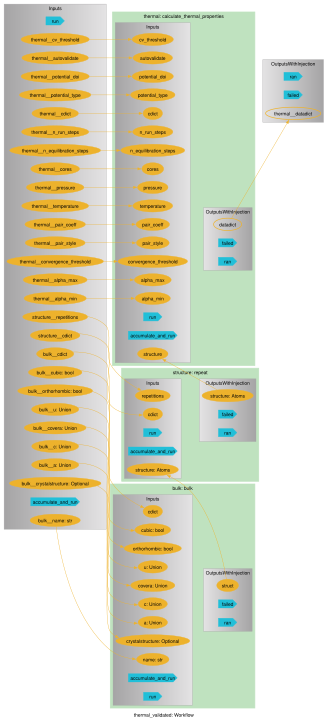

In [4]:
wf.draw(rankdir='LR', size=(10, 10))

In [5]:
res = wf.run()

LAMMPS (27 Jun 2024)
OMP_NUM_THREADS environment is not set. Defaulting to 1 thread. (src/comm.cpp:98)
  using 1 OpenMP thread(s) per MPI task
Reading data file ...
  orthogonal box = (0 0 0) to (8.61 8.61 8.61)
  1 by 1 by 1 MPI processor grid
  reading atoms ...
  54 atoms
  read_data CPU = 0.012 seconds

CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE

Your simulation uses code contributions which should be cited:
- Type Label Framework: https://doi.org/10.1021/acs.jpcb.3c08419
The log file lists these citations in BibTeX format.

CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE

Neighbor list info ...
  update: every = 1 steps, delay = 0 steps, check = yes
  max neighbors/atom: 2000, page size: 100000
  master list distance cutoff = 6.156425
  ghost atom cutoff = 6.156425
  binsize = 3.0782125, bins = 3 3 3
  1 neighbor lists, perpetual/occasional/extra = 1 0 0
  (1) pair eam/alloy, perpetual
      attributes: half, newton on
      pair build: half/

In [7]:
res['thermal__datadict']['validation']

{'temp_stable': True,
 'press_stable': False,
 'statistically_converged': True,
 'physical_range': True}

In [ ]:
cd.to_yaml('thermal_validated.yaml')